# 鐵達尼號資料清理

| 欄位名稱 | 中文名稱 | 說明 |
|---|---|---|
| survival | 生還 | 0：死亡；1：存活 |
| pclass | 艙等 | 1：一等艙／2：二等艙／3：三等艙 |
| sex | 性別 | male：男性／female：女性 |
| age | 年齡 | — |
| sibsp | 手足與配偶數 | 同乘的兄弟姊妹與配偶數 |
| parch | 父母與子女數 | 同乘的父母與子女數 |
| fare | 票價 | — |
| embarked | 乘船港代碼 | C：Cherbourg／Q：Queenstown／S：Southampton |
| class | 艙等名 | First／Second／Third |
| who | 男女兒童 | man／woman／child |
| adult_male | 成人男子 | True／False |
| deck | 甲板 | 房艙號碼首字母（A 到 G） |
| embark_town | 乘船港 | Southampton／Cherbourg／Queenstown |
| alive | 生還與否 | yes／no |
| alone | 單身 | True／False |

## 設定顯示選項

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline

# 將 matplotlib 圖表輸出格式設為 SVG 向量圖，放大不失真，在 Jupyter Notebook 中顯示更清晰
matplotlib_inline.backend_inline.set_matplotlib_formats("svg")

# 設定 NumPy 數字顯示格式：suppress=True 關閉科學記號，precision=4 只顯示小數點後 4 位
np.set_printoptions(suppress=True, precision=4)

# 設定 Pandas DataFrame 浮點數顯示格式為小數點後 4 位，讓表格數字對齊、易讀
pd.options.display.float_format = "{:.4f}".format

# 設定 matplotlib 圖表中所有文字（標題、軸標籤、刻度等）的預設字體大小為 14pt
plt.rcParams["font.size"] = 14

# 設定 matplotlib 圖表字體為 PingFang HK（蘋方-港），確保中文字能正確顯示
plt.rcParams["font.family"] = "PingFang HK"

## 載入 Titanic 資料集並顯示

In [2]:
import seaborn as sns

df_titanic = sns.load_dataset("titanic")
df_titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0000,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0000,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0000,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0000,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0000,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 更改欄位名稱為中文

In [3]:
columns_t = [
    "生還",
    "艙等",
    "性別",
    "年齡",
    "手足與配偶數",
    "父母與子女數",
    "票價",
    "乘船港代碼",
    "艙等名",
    "男女兒童",
    "成人男子",
    "甲板",
    "乘船港",
    "生還與否",
    "單身",
]

df_titanic.columns = columns_t
df_titanic.head()

,生還,艙等,性別,年齡,手足與配偶數,父母與子女數,票價,乘船港代碼,艙等名,男女兒童,成人男子,甲板,乘船港,生還與否,單身
0,0,3,male,22.0000,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0000,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0000,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0000,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0000,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 檢查缺失值

In [4]:
df_titanic.isnull().sum()

生還          0
艙等          0
性別          0
年齡        177
手足與配偶數      0
父母與子女數      0
票價          0
乘船港代碼       2
艙等名         0
男女兒童        0
成人男子        0
甲板        688
乘船港         2
生還與否        0
單身          0
dtype: int64

## 計算欄位值的數量

In [5]:
df_titanic["乘船港"].value_counts()

乘船港
Southampton    644
Cherbourg      168
Queenstown      77
Name: count, dtype: int64

In [6]:
df_titanic["生還與否"].value_counts()

生還與否
no     549
yes    342
Name: count, dtype: int64

## 統計資訊

In [7]:
df_titanic.describe()

,生還,艙等,年齡,手足與配偶數,父母與子女數,票價
count,891.0000,891.0000,714.0000,891.0000,891.0000,891.0000
mean,0.3838,2.3086,29.6991,0.5230,0.3816,32.2042
std,0.4866,0.8361,14.5265,1.1027,0.8061,49.6934
min,0.0000,1.0000,0.4200,0.0000,0.0000,0.0000
25%,0.0000,2.0000,20.1250,0.0000,0.0000,7.9104
50%,0.0000,3.0000,28.0000,0.0000,0.0000,14.4542
75%,1.0000,3.0000,38.0000,1.0000,0.0000,31.0000
max,1.0000,3.0000,80.0000,8.0000,6.0000,512.3292


## 聚合函式：依性別分組求均值

In [8]:
df_titanic.groupby("性別").mean(numeric_only=True)

,生還,艙等,年齡,手足與配偶數,父母與子女數,票價,成人男子,單身
性別,,,,,,,,
female,0.7420,2.1592,27.9157,0.6943,0.6497,44.4798,0.0000,0.4013
male,0.1889,2.3899,30.7266,0.4298,0.2357,25.5239,0.9307,0.7123


## 繪製數值型資料的直方圖

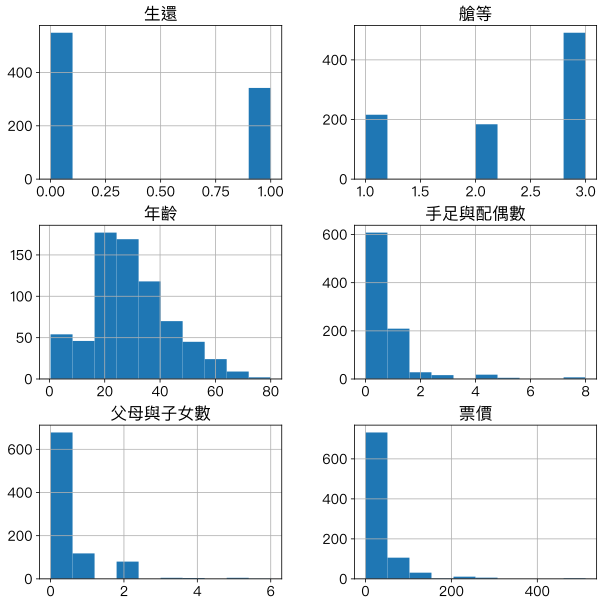

In [9]:
columns_n = ["生還", "艙等", "年齡", "手足與配偶數", "父母與子女數", "票價"]
plt.rcParams["figure.figsize"] = (10, 10)
df_titanic[columns_n].hist()
plt.show()

## 繪製分類（非數值型）資料的直條圖

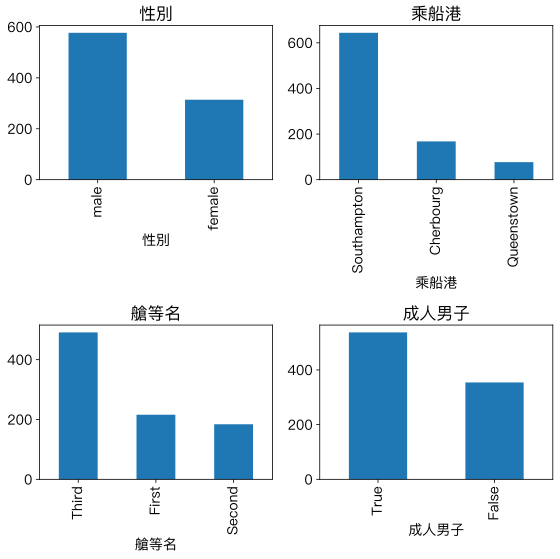

In [10]:
columns_c = ["性別", "乘船港", "艙等名", "成人男子"]
plt.rcParams["figure.figsize"] = (8, 8)
for i, name in enumerate(columns_c):
    ax = plt.subplot(2, 2, i + 1)
    df_titanic[name].value_counts().plot(kind="bar", title=name, ax=ax)
plt.tight_layout()
plt.show()